In [1]:
#Se probaron diferentes métodos de outliers multivariados: Distancia de Mahalanobis, LOF, Isolation Forest, uCBLOF
#Sobre 2 dataset:
#1- Reducido: se usaron las mismas variables de proveedores a las que se aplicó outliers univariados: monto_total_adjudicado, cant_socios, cant_apoderados, cant_autenticados, cant_sin_monto_limite, total_art_provee y periodo_preinscripcion
#2- Completo: todas las variables numéricas del dataset proveedores

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from pandas_profiling import ProfileReport
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.preprocessing import RobustScaler
from scipy.stats import chi2

from sklearn.neighbors import LocalOutlierFactor

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.ensemble import IsolationForest

from sklearn.manifold import TSNE

from sklearn.cluster import KMeans
from sklearn.neighbors import LocalOutlierFactor

from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN

In [2]:
#rutas
ruta_dataset_discretizacion = ''
ruta_dataset_outlier=''

In [3]:
#para gráficos
sns.set_theme()
sns.set_style({"xtick.bottom": True, "ytick.left": True})
paleta=['#081d58','#253494','#225ea8','#1d91c0','#41b6c4','#7fcdbb','#c7e9b4','#edf8b1','#ffffd9']
paleta1=['#225ea8']
paleta2=['#225ea8','#41b6c4']

In [ ]:
data_procesos=pd.read_csv(ruta_dataset_discretizacion+"procesos2016_2022_nuevas_var_disc_ipc.csv", sep='|', encoding='utf-8-sig')

In [5]:
data_procesos

,Unnamed: 0,num_proceso,Expediente,nombre_proceso,tipo_proceso,fecha_apertura,estado,unidad_ejecutora,servicio_administrativo_financiero,Unnamed: 0.1,...,P_monto_total_procesos,P_cant_proveedores,d_proveedores_participantes,d_ofertas_confirmadas,d_dias_recepcion_doc_soporte_fisico,d_cant_total_bienes,d_cant_total_servicios,dP_monto_total_procesos,dP_cant_proveedores,d_duracion_contrato_dias
0,0,23-0009-LPR16,EX-2016-00697885- -APN-DPYS#SGP,Adquisición de elementos de electricidad,Licitación Privada,13/10/2016 13:02 Hrs.,Adjudicado,23/000 - Dirección General de Administración - SG,301 - Secretaria General de la Presidencia de ...,0.0,...,5.517478e+06,4.0,"(8.0, 9.0]","(4.0, 5.0]","(15.0, 18.0]","(26197.5, 650697097.0]","(-0.001, 1.0]","(4117933.29, 6112646.722]","(3.0, 4.0]","(0.999, 14.0]"
1,1,23-0010-LPR16,EX-2016-01031683- -APN-DPYS#SGP,Adquisición de elementos de plomería y cerraje...,Licitación Privada,13/09/2016 11:00 Hrs.,Desierto,23/000 - Dirección General de Administración - SG,301 - Secretaria General de la Presidencia de ...,1.0,...,NaN,NaN,"(1.0, 2.0]","(-0.001, 1.0]","(10.0, 11.0]","(5833.0, 26197.5]","(-0.001, 1.0]",NaN,NaN,"(28.0, 30.0]"
2,2,23-0011-LPR16,EX-2016-01358346- -APN-DDMYA#SGP,ADQUISICIÓN INSUMOS PARA BAÑOS,Licitación Privada,19/12/2016 12:30 Hrs.,Adjudicado,23/000 - Dirección General de Administración - SG,301 - Secretaria General de la Presidencia de ...,2.0,...,5.434774e+06,1.0,"(7.0, 8.0]","(2.0, 3.0]","(6.0, 7.0]","(5833.0, 26197.5]","(-0.001, 1.0]","(4117933.29, 6112646.722]","(0.999, 2.0]","(180.0, 360.0]"
3,3,23-0012-LPR16,EX-2016-01392005- -APN-DDMYA#SGP,"Servicio anual de mantenimiento, y controles m...",Licitación Privada,30/11/2016 16:31 Hrs.,Adjudicado,23/000 - Dirección General de Administración - SG,301 - Secretaria General de la Presidencia de ...,3.0,...,4.498171e+06,1.0,"(5.0, 6.0]","(4.0, 5.0]","(-0.001, 1.0]","(1003.0, 2163.25]","(13.0, 36.0]","(4117933.29, 6112646.722]","(0.999, 2.0]","(180.0, 360.0]"
4,4,23-0014-LPU16,EX-2016-00474707- -APN-DPYS#SGP,Adquisición de indumentaria.,Licitación Pública,27/10/2016 12:00 Hrs.,Adjudicado,23/000 - Dirección General de Administración - SG,301 - Secretaria General de la Presidencia de ...,4.0,...,1.100068e+07,10.0,"(6.0, 7.0]","(5.0, 6.0]","(22.0, 383.0]","(2163.25, 5833.0]","(-0.001, 1.0]","(9564554.25, 16889709.634]","(6.0, 31.0]","(98.0, 168.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69681,69681,95-0189-CDI21,EX-2021-124397120- -APN-DCYC#MDS,CONTRATACIÓN DIRECTA CON UNA UNIVERSIDAD NACIO...,Contratación Directa,18/01/2022 10:00 Hrs.,Desierto,95/000 - Dirección General de Administración -...,311 - Ministerio de Desarrollo Social,12.0,...,NaN,NaN,"(-0.001, 1.0]","(-0.001, 1.0]",NaN,"(-0.001, 1.0]","(-0.001, 1.0]",NaN,NaN,"(180.0, 360.0]"
69682,69682,96-0054-CDI22,EX-2022-44338308- -APN-DC#HP,"ADQUISICIÓN DE ÁCIDO 2,3 - DIMERCAPTOSUCCÍNICO...",Contratación Directa,21/06/2022 13:00 Hrs.,Desierto,96 - Dirección General de Administración,908 - Hospital Nacional Profesor Alejandro Pos...,33.0,...,NaN,NaN,"(-0.001, 1.0]","(-0.001, 1.0]",NaN,"(102.0, 230.0]","(-0.001, 1.0]",NaN,NaN,"(168.0, 180.0]"
69683,69683,96-0118-CDI22,EX-2022-121335498- -APN-DC#HP,CALIBRACIÓN DE EQUIPAMIENTO Y ELEMENTOS DE MED...,Contratación Directa,23/11/2022 13:00 Hrs.,Desierto,96 - Dirección General de Administración,908 - Hospital Nacional Profesor Alejandro Pos...,42.0,...,NaN,NaN,"(-0.001, 1.0]","(-0.001, 1.0]",NaN,"(-0.001, 1.0]","(36.0, 278.0]",NaN,NaN,"(0.999, 14.0]"
69684,69684,98-0012-CDI22,EX-2022-44810023- -APN-DA#FMLCAV,ADQUISICIÓN DE VACUNAS ANTIGRIPALES,Contratación Directa,16/05/2022 11:00 Hrs.,Desierto,98/00 - Dir. Compras,101 - Fundación Miguel Lillo,36.0,...,NaN,NaN,"(-0.001, 1.0]","(-0.001, 1.0]",NaN,"(102.0, 230.0]","(-0.001, 1.0]",NaN,NaN,"(168.0, 180.0]"


In [6]:
data_procesos=data_procesos.drop(['Unnamed: 0'], axis=1)
data_procesos=data_procesos.drop(['Unnamed: 0.1'], axis=1)

### preparar el dataset
#### 1. quedarse con las variables numéricas
#### 2. imputar nulos
#### 3. normalizar 

In [7]:
#1. quedarse con las variables numéricas
data_procesos_num = data_procesos.select_dtypes(include='number')


In [8]:
data_procesos_num

,cro_cant_dias_publicar,proveedores_participantes,ofertas_confirmadas,año_apertura,periodo_apertura,dias_recepción_doc_soporte_fisico,duracion_contrato_dias,cant_total_bienes,cant_total_servicios,TOT_AGROPECUARIO,...,TOT_SERV_PROFESIONAL,TOT_SERV_NOTICIAS,TOT_SERV_BASICOS,TOT_TAPICERIA,TOT_TRANSPORTE,TOT_PROD_DEPORTIVOS,TOT_VIDRIERIA,TOT_VIGILANCIA,P_monto_total_procesos,P_cant_proveedores
0,2.0,9.0,5.0,2016,201610,16.0,7.0,65486.0,0.0,0.0,...,0.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,5.517478e+06,4.0
1,1.0,2.0,0.0,2016,201609,11.0,30.0,7957.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2,0.0,8.0,3.0,2016,201612,7.0,360.0,7440.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.434774e+06,1.0
3,2.0,6.0,5.0,2016,201611,0.0,360.0,2006.0,26.0,0.0,...,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.498171e+06,1.0
4,2.0,7.0,6.0,2016,201610,31.0,120.0,5598.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.100068e+07,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69681,0.0,0.0,0.0,2022,202201,NaN,210.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
69682,0.0,0.0,0.0,2022,202206,NaN,180.0,210.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
69683,0.0,0.0,0.0,2022,202211,NaN,14.0,0.0,51.0,0.0,...,51.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
69684,0.0,0.0,0.0,2022,202205,NaN,180.0,130.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


### se seleccionan las variables numéricas que tiene sentido para este análisis, es decir las que se usaron en outliers univariados

In [9]:
data_num = data_procesos_num[['cro_cant_dias_publicar','proveedores_participantes','ofertas_confirmadas','dias_recepción_doc_soporte_fisico','duracion_contrato_dias','cant_total_bienes','cant_total_servicios','P_monto_total_procesos','P_cant_proveedores']]

In [ ]:
#2. imputar nulos
data_num.fillna(0, inplace=True)

In [11]:
data_num.dtypes

cro_cant_dias_publicar               float64
proveedores_participantes            float64
ofertas_confirmadas                  float64
dias_recepción_doc_soporte_fisico    float64
duracion_contrato_dias               float64
cant_total_bienes                    float64
cant_total_servicios                 float64
P_monto_total_procesos               float64
P_cant_proveedores                   float64
dtype: object

In [12]:
#3. normalizar
#Robust Scaler: elimina la mediana y escala los datos de acuerdo con el rango intercuartílico. 
#Esto lo hace más robusto frente a valores atípicos

# Crear la instancia del escalador
scaler = RobustScaler()

# Escalar los datos y mantenerlos como DataFrame
data_num_rs = pd.DataFrame(
    scaler.fit_transform(data_num),
    columns=data_num.columns,
    index=data_num.index
)

In [13]:
#lee el dataset que tiene los outliers univariados
#proveedores.csv es el que tiene los outliers univariados solamente
#proveedoresOutliers.csv tiene los univariados y multivariados hasta IF
dataset = pd.read_csv(ruta_dataset_outlier+"procesos_outliers_uni.csv", sep='|', encoding='utf-8-sig')

C:\Users\Vanina\AppData\Local\Temp\ipykernel_9136\2113662733.py:4: DtypeWarning: Columns (38,41,42,43,46) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv(ruta_dataset_outlier+"procesos_outliers_uni.csv", sep='|', encoding='utf-8-sig')


In [14]:
dataset =dataset.drop(columns=['Unnamed: 0','Unnamed: 0']) 

In [15]:
dataset

,num_proceso,Expediente,nombre_proceso,tipo_proceso,fecha_apertura,estado,unidad_ejecutora,servicio_administrativo_financiero,num_expediente,etapa,...,dP_cant_proveedores,cro_cant_dias_publicar_outliers,proveedores_participantes_outliers,ofertas_confirmadas_outliers,dias_recepción_doc_soporte_fisico_outliers,duracion_contrato_dias_outliers,cant_total_bienes_outliers,cant_total_servicios_outliers,P_monto_total_procesos_outliers,P_cant_proveedores_outliers
0,23-0009-LPR16,EX-2016-00697885- -APN-DPYS#SGP,Adquisición de elementos de electricidad,Licitación Privada,13/10/2016 13:02 Hrs.,Adjudicado,23/000 - Dirección General de Administración - SG,301 - Secretaria General de la Presidencia de ...,EX-2016-00697885- -APN-DPYS#SGP,Única,...,"(3.0, 4.0]",True,False,False,False,False,True,False,False,True
1,23-0010-LPR16,EX-2016-01031683- -APN-DPYS#SGP,Adquisición de elementos de plomería y cerraje...,Licitación Privada,13/09/2016 11:00 Hrs.,Desierto,23/000 - Dirección General de Administración - SG,301 - Secretaria General de la Presidencia de ...,EX-2016-01031683- -APN-DPYS#SGP,Única,...,NaN,True,False,False,False,False,True,False,False,False
2,23-0011-LPR16,EX-2016-01358346- -APN-DDMYA#SGP,ADQUISICIÓN INSUMOS PARA BAÑOS,Licitación Privada,19/12/2016 12:30 Hrs.,Adjudicado,23/000 - Dirección General de Administración - SG,301 - Secretaria General de la Presidencia de ...,EX-2016-01358346- -APN-DDMYA#SGP,Única,...,"(0.999, 2.0]",False,False,False,False,False,True,False,False,False
3,23-0012-LPR16,EX-2016-01392005- -APN-DDMYA#SGP,"Servicio anual de mantenimiento, y controles m...",Licitación Privada,30/11/2016 16:31 Hrs.,Adjudicado,23/000 - Dirección General de Administración - SG,301 - Secretaria General de la Presidencia de ...,EX-2016-01392005- -APN-DDMYA#SGP,Única,...,"(0.999, 2.0]",True,False,False,False,False,True,True,False,False
4,23-0014-LPU16,EX-2016-00474707- -APN-DPYS#SGP,Adquisición de indumentaria.,Licitación Pública,27/10/2016 12:00 Hrs.,Adjudicado,23/000 - Dirección General de Administración - SG,301 - Secretaria General de la Presidencia de ...,EX-2016-00474707- -APN-DPYS#SGP,Única,...,"(6.0, 31.0]",True,False,False,True,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69681,95-0189-CDI21,EX-2021-124397120- -APN-DCYC#MDS,CONTRATACIÓN DIRECTA CON UNA UNIVERSIDAD NACIO...,Contratación Directa,18/01/2022 10:00 Hrs.,Desierto,95/000 - Dirección General de Administración -...,311 - Ministerio de Desarrollo Social,EX-2021-124397120- -APN-DCYC#MDS,Única,...,NaN,False,False,False,False,False,False,False,False,False
69682,96-0054-CDI22,EX-2022-44338308- -APN-DC#HP,"ADQUISICIÓN DE ÁCIDO 2,3 - DIMERCAPTOSUCCÍNICO...",Contratación Directa,21/06/2022 13:00 Hrs.,Desierto,96 - Dirección General de Administración,908 - Hospital Nacional Profesor Alejandro Pos...,EX-2022-44338308- -APN-DC#HP,Única,...,NaN,False,False,False,False,False,False,False,False,False
69683,96-0118-CDI22,EX-2022-121335498- -APN-DC#HP,CALIBRACIÓN DE EQUIPAMIENTO Y ELEMENTOS DE MED...,Contratación Directa,23/11/2022 13:00 Hrs.,Desierto,96 - Dirección General de Administración,908 - Hospital Nacional Profesor Alejandro Pos...,EX-2022-121335498- -APN-DC#HP,Única,...,NaN,False,False,False,False,False,False,True,False,False
69684,98-0012-CDI22,EX-2022-44810023- -APN-DA#FMLCAV,ADQUISICIÓN DE VACUNAS ANTIGRIPALES,Contratación Directa,16/05/2022 11:00 Hrs.,Desierto,98/00 - Dir. Compras,101 - Fundación Miguel Lillo,EX-2022-44810023- -APN-DA#FMLCAV,Única,...,NaN,False,False,False,False,False,False,False,False,False


## Distancia de Mahalanobis

In [15]:
#Normalizar los datos antes de calcular la distancia de Mahalanobis no es estrictamente necesario, 
#pero es recomendable si las variables están en diferentes escalas. 
#La normalización puede ayudar a garantizar que cada variable contribuya de manera equitativa a la distancia de Mahalanobis
#y a evitar que una variable con una escala más amplia domine la medida de distancia.



In [16]:
#create función para calcular la distancia de Mahalanobis 
def mahalanobis (df):
   # Calcular la media y la matriz de covarianza de los datos
    mean_vector = np.mean(df, axis=0)
    cov_matrix = np.cov(df.T)

    # Calcular la inversa de la matriz de covarianza
    inv_cov_matrix = np.linalg.inv(cov_matrix)

    # Calcular la distancia de Mahalanobis para cada fila en el DataFrame
    mahalanobis_distances = []
    for index, row in df.iterrows():
        diff = row - mean_vector
        mahalanobis_distance = np.sqrt(np.dot(np.dot(diff, inv_cov_matrix), diff.T))
        mahalanobis_distances.append(mahalanobis_distance)
        
    return mahalanobis_distances

In [17]:
#Carga el dataset Reducido
data_outliers =data_num_rs
data_outliers

,cro_cant_dias_publicar,proveedores_participantes,ofertas_confirmadas,dias_recepción_doc_soporte_fisico,duracion_contrato_dias,cant_total_bienes,cant_total_servicios,P_monto_total_procesos,P_cant_proveedores
0,2.0,1.000000,0.75,2.000,-0.247761,136.420833,0.00,2.003552,3.0
1,1.0,-0.166667,-0.50,1.375,-0.179104,16.568750,0.00,-0.171442,-1.0
2,0.0,0.833333,0.25,0.875,0.805970,15.491667,0.00,1.970950,0.0
3,2.0,0.500000,0.75,0.000,0.805970,4.170833,6.50,1.601740,0.0
4,2.0,0.666667,1.00,3.875,0.089552,11.654167,0.00,4.165034,9.0
...,...,...,...,...,...,...,...,...,...
69681,0.0,-0.500000,-0.50,0.000,0.358209,-0.008333,0.25,-0.171442,-1.0
69682,0.0,-0.500000,-0.50,0.000,0.268657,0.429167,0.00,-0.171442,-1.0
69683,0.0,-0.500000,-0.50,0.000,-0.226866,-0.008333,12.75,-0.171442,-1.0
69684,0.0,-0.500000,-0.50,0.000,0.268657,0.262500,0.00,-0.171442,-1.0


In [18]:
#Reducido
# crear una nueva columna en el marco de datos que contenga la distancia de Mahalanobis para cada fila
data_outliers['mahalanobis'] = mahalanobis(data_outliers)
dataset['mahalanobis_varuni']= mahalanobis(data_outliers)
#todos los datos data_proveedores_num[['cant_procesos_addicado','monto_total_adjudicado','periodo_preinscripcion','antiguedad','cant_socios','cant_apercibimientos','cant_suspensiones','cant_antecedentes','cant_Apoderado','cant_representante','cant_autenticado','cant_noAutenticado','cant_sinMontoLimite','cant_MontoLimite','TOT_AGROPECUARIO','TOT_ALIMENTOS','TOT_ALQUILER','TOT_ART_HOGAR','TOT_BANCO','TOT_BAZAR','TOT_CARPINTERIA','TOT_CEREMONIAL','TOT_CERRAJERIA','TOT_CINE','TOT_COMBUSTIBLES','TOT_CONCESION','TOT_CONSTRUCCION','TOT_CULTURA','TOT_ELECTRICIDAD','TOT_LIMPIEZA','TOT_MUEBLES','TOT_EQUIPO_MILITAR','TOT_EQUIPOS','TOT_FERRETERIA','TOT_GASES_IND','TOT_HERRAMIENTAS','TOT_HERRERIA','TOT_IMPRENTA','TOT_INDUMENTARIA','TOT_INFORMATICA','TOT_INMUEBLES','TOT_INSUMO_ARMAMENTO','TOT_JOYERIA','TOT_LIBRERIA','TOT_MANTENIMIENTO','TOT_METALES','TOT_METALURGIA','TOT_CONSTRUCCION.1','TOT_NAUTICA','TOT_PINTURAS','TOT_PROD_MEDICOS','TOT_PROD_VETERINARIOS','TOT_QUIMICOS','TOT_REPUESTOS','TOT_PLOMERIA','TOT_SERV_PROFESIONAL','TOT_SERV_NOTICIAS','TOT_SERV_BASICOS','TOT_TAPICERIA','TOT_TRANSPORTE','TOT_PROD_DEPORTIVOS','TOT_VIDRIERIA','TOT_VIGILANCIA','total_articulos_provee']])



In [19]:
#reducido
#Luego, calculamos el percentil 95 de la distribución chi-cuadrado, que es el umbral que usamos para identificar valores atípicos.

# Calcular el percentil 99 de la distribución chi-cuadrado
threshold = np.percentile(data_outliers['mahalanobis'], 99)
threshold


7.201262274696431

In [20]:
#reducido
data_outliers['Outlier'] = np.array(data_outliers['mahalanobis']) > threshold
dataset['outliers_mahalanobis_varuni']= np.array(dataset['mahalanobis_varuni']) > threshold

In [21]:
data_outliers

,cro_cant_dias_publicar,proveedores_participantes,ofertas_confirmadas,dias_recepción_doc_soporte_fisico,duracion_contrato_dias,cant_total_bienes,cant_total_servicios,P_monto_total_procesos,P_cant_proveedores,mahalanobis,Outlier
0,2.0,1.000000,0.75,2.000,-0.247761,136.420833,0.00,2.003552,3.0,3.044548,False
1,1.0,-0.166667,-0.50,1.375,-0.179104,16.568750,0.00,-0.171442,-1.0,1.714822,False
2,0.0,0.833333,0.25,0.875,0.805970,15.491667,0.00,1.970950,0.0,1.747074,False
3,2.0,0.500000,0.75,0.000,0.805970,4.170833,6.50,1.601740,0.0,2.927235,False
4,2.0,0.666667,1.00,3.875,0.089552,11.654167,0.00,4.165034,9.0,6.788917,False
...,...,...,...,...,...,...,...,...,...,...,...
69681,0.0,-0.500000,-0.50,0.000,0.358209,-0.008333,0.25,-0.171442,-1.0,1.132250,False
69682,0.0,-0.500000,-0.50,0.000,0.268657,0.429167,0.00,-0.171442,-1.0,1.132378,False
69683,0.0,-0.500000,-0.50,0.000,-0.226866,-0.008333,12.75,-0.171442,-1.0,1.140243,False
69684,0.0,-0.500000,-0.50,0.000,0.268657,0.262500,0.00,-0.171442,-1.0,1.132377,False


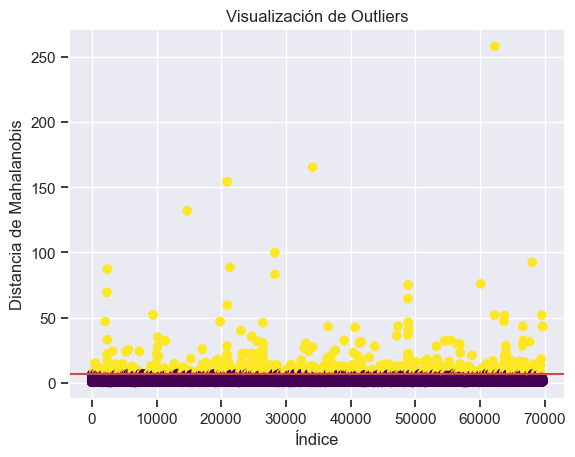

In [142]:
# Visualizar los outliers
plt.scatter(data_outliers.index, data_outliers['mahalanobis'], c=data_outliers['Outlier'], cmap='viridis')
plt.axhline(y=threshold, color='r', linestyle='-')
plt.xlabel('Índice')
plt.ylabel('Distancia de Mahalanobis')
plt.title('Visualización de Outliers')
plt.show()

In [22]:
# Contar cuántos valores son outliers
outlier_count = data_outliers['Outlier'].sum()
print("Número de outliers:", outlier_count)

Número de outliers: 697


In [193]:
#Comparar la media de cada variable entre outliers y no-outliers
outliers = data_outliers[data_outliers['Outlier'] == True]
no_outliers = data_outliers[data_outliers['Outlier'] == False]

# Comparar medias
mean_diff = outliers.mean() - no_outliers.mean()
mean_diff_sorted = mean_diff.abs().sort_values(ascending=False)

print(mean_diff_sorted)  

cant_total_servicios                 1.584226e+06
cant_total_bienes                    1.072324e+04
P_monto_total_procesos               1.432011e+02
mahalanobis                          1.256248e+01
P_cant_proveedores                   3.243175e+00
dias_recepción_doc_soporte_fisico    2.698669e+00
duracion_contrato_dias               2.539996e+00
proveedores_participantes            2.073469e+00
ofertas_confirmadas                  1.702764e+00
cro_cant_dias_publicar               1.293069e+00
Outlier                              1.000000e+00
dtype: float64


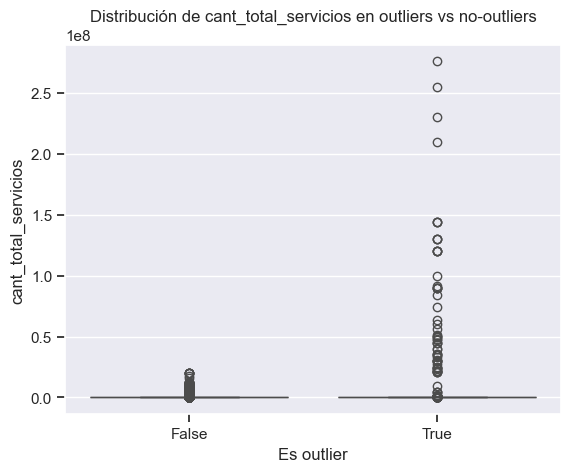

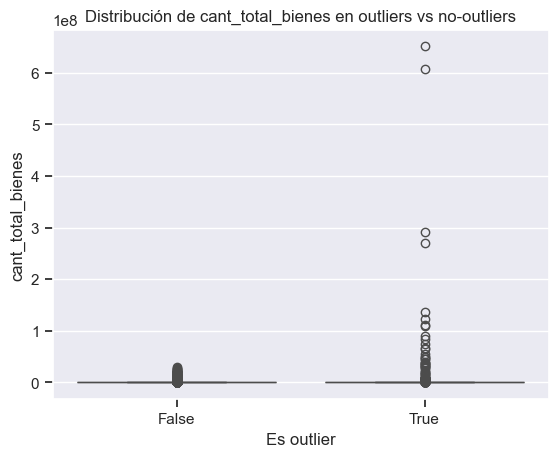

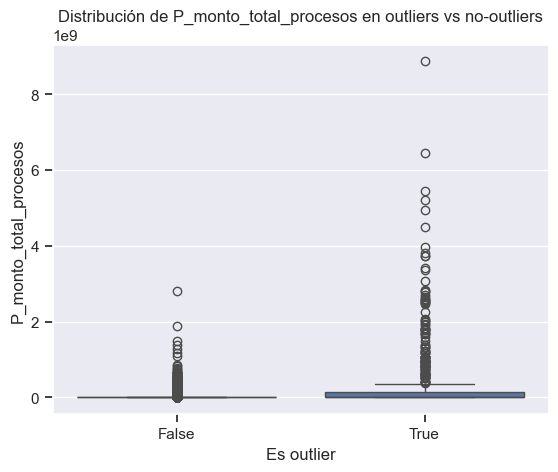

In [99]:
top_vars = ['cant_total_servicios', 'cant_total_bienes', 'P_monto_total_procesos']

for var in top_vars:
    sns.boxplot(x=data_outliers['Outlier'], y=dataset[var])
    plt.title(f'Distribución de {var} en outliers vs no-outliers')
    plt.xlabel('Es outlier')
    plt.ylabel(var)
    plt.show()

In [101]:
#Opción B: Estimar la contribución de cada variable a la distancia de Mahalanobis
# Reescalar el dataset nuevamente si hace falta
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(data_num), columns=data_num.columns)

# Calcular componentes individuales de la distancia
mean_vector = X_scaled.mean().values
cov_matrix = np.cov(X_scaled.T)
inv_cov_matrix = np.linalg.inv(cov_matrix)

def mahalanobis_contributions(row):
    diff = row - mean_vector
    contribs = diff * np.dot(inv_cov_matrix, diff)
    return contribs

# Aplicar solo a los outliers
contrib_matrix = X_scaled[data_num_rs['Outlier'] == True].apply(mahalanobis_contributions, axis=1, result_type='expand')
contrib_mean = contrib_matrix.abs().mean().sort_values(ascending=False)

print(contrib_mean.head(10))  # Las variables que más aportan a la distancia

cant_total_bienes                    98.861288
cant_total_servicios                 98.345434
duracion_contrato_dias               97.503226
P_monto_total_procesos               93.909545
proveedores_participantes            41.167819
dias_recepción_doc_soporte_fisico    37.556210
ofertas_confirmadas                  26.616750
cro_cant_dias_publicar               19.884050
P_cant_proveedores                   17.107291
dtype: float64


In [150]:
#top 10 de procesos outliers
#dataset 
# Filtrar solo los outliers
outliers = data_num_rs[data_num_rs['Outlier'] == True]

# Ordenar por distancia de Mahalanobis de mayor a menor
outliers_sorted = outliers.sort_values(by='mahalanobis', ascending=False)

# Tomar el top 10
top_10_outliers = outliers_sorted.head(11)

# Recuperar la info original de esos casos (opcional y muy útil)
top_10_info = dataset.loc[top_10_outliers.index]



In [151]:
top_10_outliers

,cro_cant_dias_publicar,proveedores_participantes,ofertas_confirmadas,dias_recepción_doc_soporte_fisico,duracion_contrato_dias,cant_total_bienes,cant_total_servicios,P_monto_total_procesos,P_cant_proveedores,mahalanobis,Outlier
62273,0.0,-0.333333,-0.25,0.625,1088.194030,-6.250000e-03,0.00,0.148699,0.0,258.023987,True
34113,2.0,6.500000,6.75,0.000,0.805970,1.355619e+06,0.00,1515.904668,30.0,165.386393,True
20894,2.0,4.833333,6.00,0.000,0.805970,1.264952e+06,0.00,1370.538502,27.0,154.309760,True
14729,2.0,-0.333333,-0.25,0.000,0.820896,-8.333333e-03,1096500.00,6479.865158,1.0,131.992342,True
28288,0.0,-0.333333,-0.25,0.875,0.358209,-8.333333e-03,68940543.75,159.267264,1.0,99.796142,True
68065,2.0,-0.166667,-0.50,0.000,0.805970,4.166666e+04,63750000.00,-0.171442,-1.0,92.424868,True
21349,0.0,52.666667,25.75,1.125,-0.268657,-8.333333e-03,0.00,3.146308,30.0,88.630972,True
2411,0.0,-0.166667,-0.25,0.250,0.805970,-8.333333e-03,0.75,4276.081016,0.0,87.266951,True
28292,0.0,-0.333333,-0.25,0.750,0.358209,-8.333333e-03,57578550.00,47.513830,1.0,83.346335,True
60115,2.0,0.500000,0.25,0.000,0.268657,-8.333333e-03,52500000.00,85.989557,0.0,75.990937,True


In [154]:
#guardar el dataset
#top_10_outliers.to_csv(ruta_dataset_outlier+"top10_mahalanobis.csv", sep='|', encoding='utf-8-sig')

In [206]:
#reducido
#hacer este mismo cálculo con las variables sin normalizar

data_num = data_procesos[['cro_cant_dias_publicar','proveedores_participantes','ofertas_confirmadas','dias_recepción_doc_soporte_fisico','duracion_contrato_dias','cant_total_bienes','cant_total_servicios','P_monto_total_procesos','P_cant_proveedores']]
data_num.fillna(0, inplace=True)
data_num

C:\Users\Vanina\AppData\Local\Temp\ipykernel_13132\868049687.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_num.fillna(0, inplace=True)


,cro_cant_dias_publicar,proveedores_participantes,ofertas_confirmadas,dias_recepción_doc_soporte_fisico,duracion_contrato_dias,cant_total_bienes,cant_total_servicios,P_monto_total_procesos,P_cant_proveedores
0,2.0,9.0,5.0,16.0,7.0,65486.0,0.0,5.517478e+06,4.0
1,1.0,2.0,0.0,11.0,30.0,7957.0,0.0,0.000000e+00,0.0
2,0.0,8.0,3.0,7.0,360.0,7440.0,0.0,5.434774e+06,1.0
3,2.0,6.0,5.0,0.0,360.0,2006.0,26.0,4.498171e+06,1.0
4,2.0,7.0,6.0,31.0,120.0,5598.0,0.0,1.100068e+07,10.0
...,...,...,...,...,...,...,...,...,...
69681,0.0,0.0,0.0,0.0,210.0,0.0,1.0,0.000000e+00,0.0
69682,0.0,0.0,0.0,0.0,180.0,210.0,0.0,0.000000e+00,0.0
69683,0.0,0.0,0.0,0.0,14.0,0.0,51.0,0.000000e+00,0.0
69684,0.0,0.0,0.0,0.0,180.0,130.0,0.0,0.000000e+00,0.0


In [207]:
# crear una nueva columna en el marco de datos que contenga la distancia de Mahalanobis para cada fila
data_num['mahalanobis'] = mahalanobis(data_num)
x2 = np.percentile(data_num['mahalanobis'], 99)
print(x2)
data_num['Outlier'] = np.array(data_num['mahalanobis']) > x2


0.8574946932916002


C:\Users\Vanina\AppData\Local\Temp\ipykernel_13132\1495241063.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_num['mahalanobis'] = mahalanobis(data_num)
C:\Users\Vanina\AppData\Local\Temp\ipykernel_13132\1495241063.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_num['Outlier'] = np.array(data_num['mahalanobis']) > x2


In [208]:
data_num

,cro_cant_dias_publicar,proveedores_participantes,ofertas_confirmadas,dias_recepción_doc_soporte_fisico,duracion_contrato_dias,cant_total_bienes,cant_total_servicios,P_monto_total_procesos,P_cant_proveedores,mahalanobis,Outlier
0,2.0,9.0,5.0,16.0,7.0,65486.0,0.0,5.517478e+06,4.0,3.044548,True
1,1.0,2.0,0.0,11.0,30.0,7957.0,0.0,0.000000e+00,0.0,1.714822,True
2,0.0,8.0,3.0,7.0,360.0,7440.0,0.0,5.434774e+06,1.0,1.747074,True
3,2.0,6.0,5.0,0.0,360.0,2006.0,26.0,4.498171e+06,1.0,2.927235,True
4,2.0,7.0,6.0,31.0,120.0,5598.0,0.0,1.100068e+07,10.0,6.788917,True
...,...,...,...,...,...,...,...,...,...,...,...
69681,0.0,0.0,0.0,0.0,210.0,0.0,1.0,0.000000e+00,0.0,1.132250,True
69682,0.0,0.0,0.0,0.0,180.0,210.0,0.0,0.000000e+00,0.0,1.132378,True
69683,0.0,0.0,0.0,0.0,14.0,0.0,51.0,0.000000e+00,0.0,1.140243,True
69684,0.0,0.0,0.0,0.0,180.0,130.0,0.0,0.000000e+00,0.0,1.132377,True


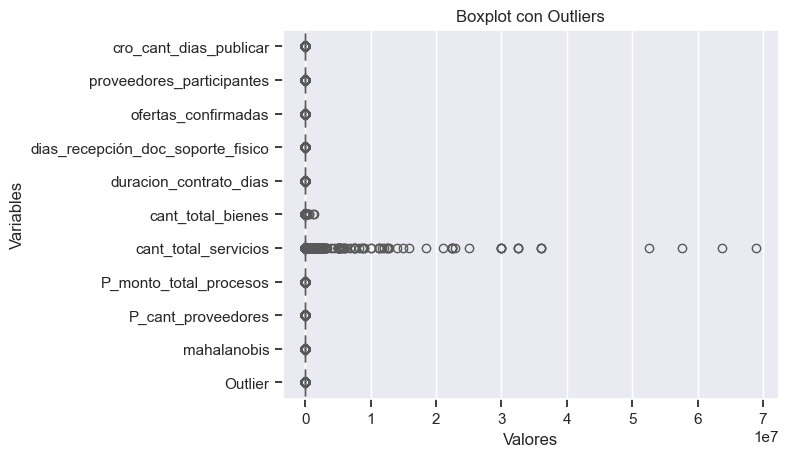

In [45]:
# Visualizar los outliers usando un boxplot
sns.boxplot(data=data_outliers, orient="h", palette="Set2")
plt.title('Boxplot con Outliers')
plt.xlabel('Valores')
plt.ylabel('Variables')
plt.show()

C:\Users\27273398320\AppData\Local\Temp\1\ipykernel_12728\3294059318.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=9)


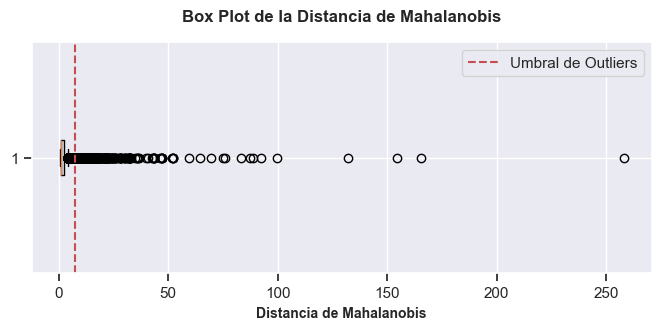

In [82]:
plt.figure(figsize=(8, 3))
plt.boxplot(data_outliers['mahalanobis'], vert=False)
# Leyenda con tamaño de fuente personalizado
plt.legend(fontsize=9)
plt.axvline(x=threshold, color='r', linestyle='--', label='Umbral de Outliers')
plt.xlabel('Distancia de Mahalanobis', fontsize=10, weight='bold')
plt.title('Box Plot de la Distancia de Mahalanobis', fontsize=12, weight='bold', pad=15)
plt.legend()
plt.show()

In [23]:
# Aplicar t-SNE sobre dataset reducido
tsne = TSNE(n_components=2, random_state=42)
data_tsne = tsne.fit_transform(data_outliers)

C:\Users\Vanina\anaconda3\envs\tesis_env\lib\site-packages\sklearn\manifold\_t_sne.py:800: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\Vanina\anaconda3\envs\tesis_env\lib\site-packages\sklearn\manifold\_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


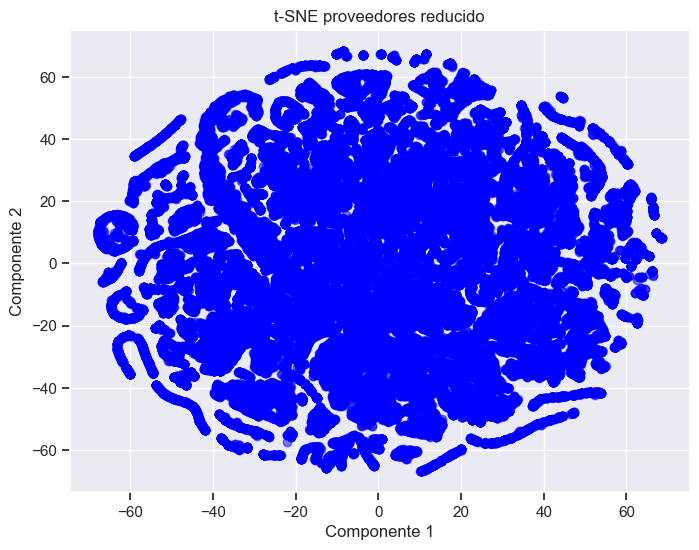

In [24]:
# Visualizar los resultados
plt.figure(figsize=(8, 6))
plt.scatter(data_tsne[:, 0], data_tsne[:, 1], color='blue', alpha=0.5)
plt.title('t-SNE proveedores reducido')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.grid(True)
plt.show()

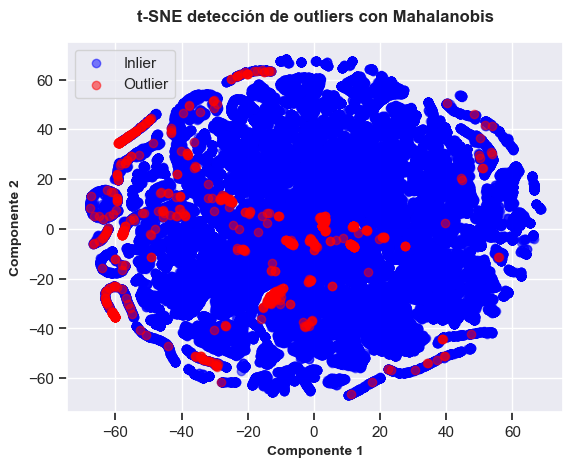

In [25]:
# se agregó después si se corre en orden va a dar error

# Mapear los valores booleanos a categorías
dataset['outliers_mahalanobis_varunic'] = dataset['outliers_mahalanobis_varuni'].map({True: 'Outlier', False: 'Inlier'})


categorias = dataset['outliers_mahalanobis_varunic'].unique()
colores = ['blue', 'red']

for i, categoria in enumerate(categorias):
    indices = dataset['outliers_mahalanobis_varunic'] == categoria
    plt.scatter(data_tsne[indices, 0], data_tsne[indices, 1], color=colores[i], alpha=0.5, label=categoria)

plt.title('t-SNE detección de outliers con Mahalanobis', fontsize=12, weight='bold', pad=15)
plt.xlabel('Componente 1', fontsize=10, weight='bold')
plt.ylabel('Componente 2', fontsize=10, weight='bold')
plt.legend()
plt.grid(True)
plt.show()

dataset = dataset.drop(columns=['outliers_mahalanobis_varunic'])

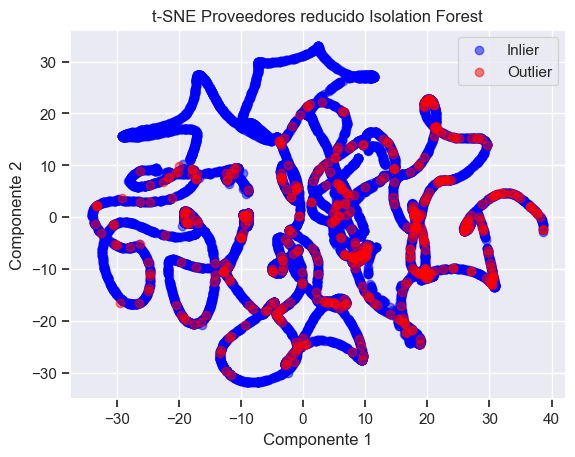

In [87]:
#Completo
# se agregó después si se corre en orden va a dar error

# Mapear los valores booleanos a categorías
dataset['Outlier_mahalanobis_vartotc'] = dataset['Outlier_mahalanobis_vartot'].map({True: 'Outlier', False: 'Inlier'})


categorias = dataset['Outlier_mahalanobis_vartotc'].unique()
colores = ['blue', 'red']

for i, categoria in enumerate(categorias):
    indices = dataset['Outlier_mahalanobis_vartotc'] == categoria
    plt.scatter(data_tsneC[indices, 0], data_tsneC[indices, 1], color=colores[i], alpha=0.5, label=categoria)

plt.title('t-SNE Proveedores reducido Isolation Forest')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.legend()
plt.grid(True)
plt.show()

dataset = dataset.drop(columns=['Outlier_mahalanobis_vartotc'])

In [18]:
# Contar cuántos valores son outliers
outlier_count = data_proveedores_num['Outlier'].sum()
print("Número de outliers:", outlier_count)

Número de outliers: 471


In [138]:
outlier_count = dataset['Outlier_mahalanobis_vartot'].sum()
print("Número de outliers:", outlier_count)

Número de outliers: 471


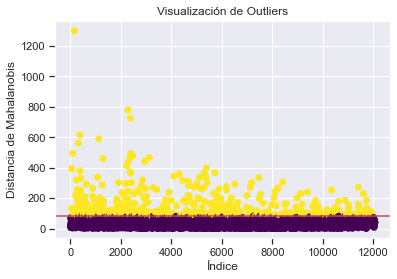

In [71]:
# Visualizar los outliers
plt.scatter(data_proveedores_num.index, data_proveedores_num['mahalanobis'], c=data_proveedores_num['Outlier'], cmap='viridis')
plt.axhline(y=threshold, color='r', linestyle='-')
plt.xlabel('Índice')
plt.ylabel('Distancia de Mahalanobis')
plt.title('Visualización de Outliers')
plt.show()

In [139]:
dataset.to_csv(ruta_dataset_outlier+"proveedoresOutliers.csv", sep='|', encoding='utf-8-sig')

#Se prueban métodos de reducción de dimensiones
#Vemos que PCA no es una opción viable para este dataset por el gráfico que queda
#Tsne es la opción correcta

Varianza explicada por cada componente: [9.93037751e-01 6.10480711e-03 5.43453439e-04 3.04623842e-04]
   Componente 1  Componente 2  Componente 3  Componente 4
0   -236.503125     -3.052811      8.821349     11.367457
1   -236.509847     -4.131951      8.081905     -7.142165
2   -236.495526     -3.926140      2.748424      1.239872
3   -236.508214     -0.587015     15.610511     18.942857
4    771.569038     -2.977555     -0.666847     -0.858991


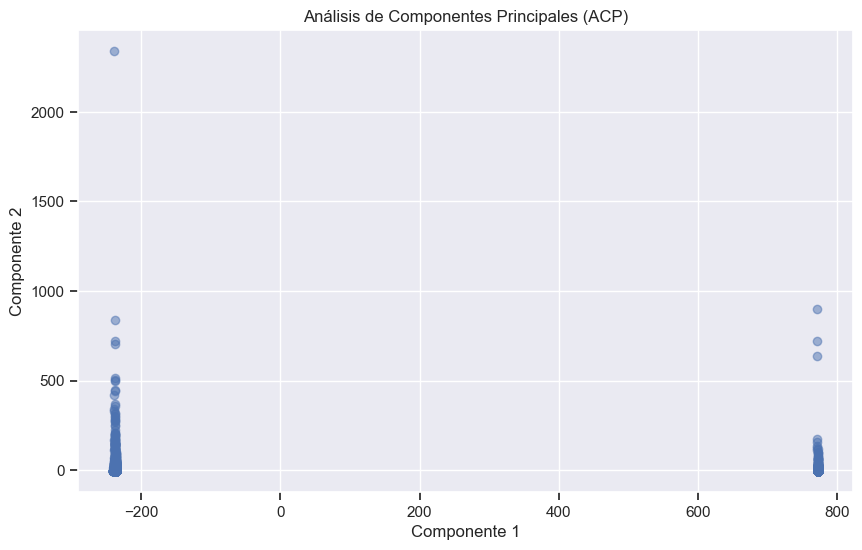

In [86]:
#calcular PCA para utilizar en los gráficos
# Inicializar el objeto PCA con el número de componentes deseados
n_components = 4  # Por ejemplo, queremos reducir a 2 componentes
pca = PCA(n_components=n_components)

# Aplicar PCA a tus datos
X_pca = pca.fit_transform(data_proveedores_outliers)

# Crear un nuevo DataFrame con las componentes principales
df_pca = pd.DataFrame(data=X_pca, columns=['Componente 1', 'Componente 2','Componente 3','Componente 4'])

# Visualizar la varianza explicada por cada componente
print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)

# Visualizar el DataFrame con las componentes principales
print(df_pca.head())

# Graficar las componentes principales
plt.figure(figsize=(10, 6))
plt.scatter(df_pca['Componente 1'], df_pca['Componente 2'], alpha=0.5)
plt.title('Análisis de Componentes Principales (ACP)')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.grid(True)
plt.show()

C:\Users\Vanina\AppData\Local\Temp/ipykernel_5292/3061165135.py:13: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


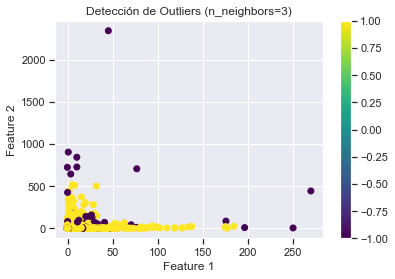

C:\Users\Vanina\AppData\Local\Temp/ipykernel_5292/3061165135.py:13: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


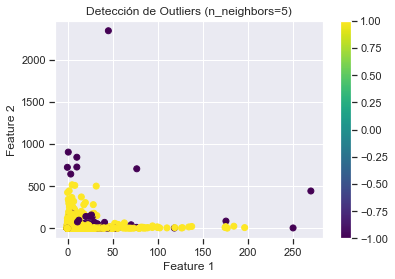

C:\Users\Vanina\AppData\Local\Temp/ipykernel_5292/3061165135.py:13: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


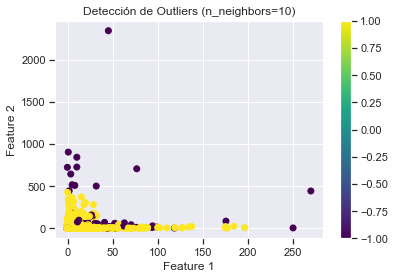

C:\Users\Vanina\AppData\Local\Temp/ipykernel_5292/3061165135.py:13: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


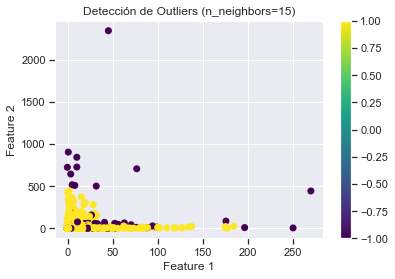

C:\Users\Vanina\AppData\Local\Temp/ipykernel_5292/3061165135.py:13: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


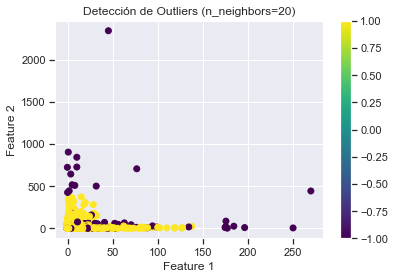

In [150]:
# Experimentar con diferentes valores de n_neighbors
n_neighbors_values = [3, 5, 10, 15, 20]

for n_neighbors in n_neighbors_values:
    lof = LocalOutlierFactor(n_neighbors=n_neighbors)
    y_pred = lof.fit_predict(data_proveedores_outliers)
    
    # Visualizar los resultados de la detección de outliers
    plt.scatter(data_proveedores_outliers.iloc[:, 0], data_proveedores_outliers.iloc[:, 1], c=y_pred, cmap='viridis')
    plt.title(f'Detección de Outliers (n_neighbors={n_neighbors})')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.colorbar()
    plt.show()

## Métod Local Outlier Factor (LOF)

In [ ]:
data_num = data_procesos_num[['cro_cant_dias_publicar','proveedores_participantes','ofertas_confirmadas','dias_recepción_doc_soporte_fisico','duracion_contrato_dias','cant_total_bienes','cant_total_servicios','P_monto_total_procesos','P_cant_proveedores']]

data_num.fillna(0, inplace=True)

# Crear la instancia del escalador
scaler = RobustScaler()

# Escalar los datos y mantenerlos como DataFrame
data_num_rs = pd.DataFrame(
    scaler.fit_transform(data_num),
    columns=data_num.columns,
    index=data_num.index
)
data_outliers =data_num_rs
data_outliers

In [31]:
# Entrenar el modelo LOF
lof = LocalOutlierFactor(n_neighbors=14)  # Definir el número de vecinos a considerar
outlier_scores = lof.fit_predict(data_outliers)  # Calcular los scores de los outliers


In [39]:
# Entrenar el modelo LOF

# Experimentar con diferentes valores de n_neighbors
n_neighbors_values = [3, 5, 10, 11, 12, 13, 14,15,16,17,18, 20,25,30,35,40,45,50]

cant_outliers = []

for n_neighbors in n_neighbors_values:
    lof = LocalOutlierFactor(n_neighbors=n_neighbors)
    outlier_scores = lof.fit_predict(data_num_rs)
    outliers = data_num_rs[outlier_scores == -1]
    cant_outliers.append(len(outliers))


In [40]:
cant_outliers

[8159,
 6309,
 4827,
 4711,
 4621,
 4536,
 4480,
 4501,
 4455,
 4433,
 4415,
 4417,
 4334,
 4200,
 4035,
 4010,
 4067,
 3990]

C:\Users\27273398320\AppData\Local\Temp\1\ipykernel_12728\3496287347.py:18: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist = np.abs(np.cross(end - start, start - point)) / np.linalg.norm(end - start)


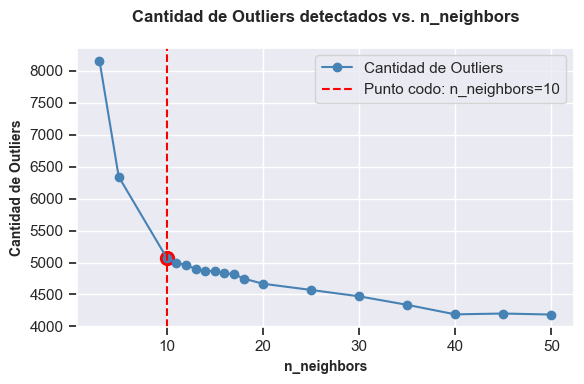

In [90]:
##Cuál elegir?

# Función para detectar el "punto codo" usando el método de la máxima distancia al segmento línea entre extremos
def find_elbow_point(x, y):
    # Normalizar valores
    x_norm = (x - np.min(x)) / (np.max(x) - np.min(x))
    y_norm = (y - np.min(y)) / (np.max(y) - np.min(y))

    # Punto inicial y final
    start = np.array([x_norm[0], y_norm[0]])
    end = np.array([x_norm[-1], y_norm[-1]])

    # Calcular distancias de cada punto a la línea
    distances = []
    for i in range(len(x_norm)):
        point = np.array([x_norm[i], y_norm[i]])
        # Distancia punto a línea (start-end)
        dist = np.abs(np.cross(end - start, start - point)) / np.linalg.norm(end - start)
        distances.append(dist)
    # El índice con mayor distancia es el "codo"
    return np.argmax(distances)

# Encontrar el índice del codo
elbow_index = find_elbow_point(np.array(n_neighbors_values), np.array(cant_outliers))

# Graficar
plt.figure(figsize=(6,4))
plt.plot(n_neighbors_values, cant_outliers, marker='o', linestyle='-', color='steelblue', label='Cantidad de Outliers')
plt.axvline(x=n_neighbors_values[elbow_index], color='red', linestyle='--', label=f'Punto codo: n_neighbors={n_neighbors_values[elbow_index]}')
plt.scatter(n_neighbors_values[elbow_index], cant_outliers[elbow_index], color='red', s=100)
plt.title('Cantidad de Outliers detectados vs. n_neighbors\n', fontsize=12, weight='bold')
plt.xlabel('n_neighbors', fontsize=10, weight='bold')
plt.ylabel('Cantidad de Outliers', fontsize=10 ,weight='bold')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [41]:
# Entrenar el modelo LOF
lof = LocalOutlierFactor(n_neighbors=14, contamination=0.01)  # Definir el número de vecinos a considerar
y_pred = lof.fit_predict(data_num_rs)  # Calcular los scores de los outliers
# Suponiendo que `X` es tu matriz de características
lof_scores = -lof.negative_outlier_factor_ 
# Agregar las etiquetas de outliers al DataFrame
#data_proveedores_num['Outlier'] = y_pred
dataset['outliers_lof_vartot']= y_pred == -1

# Contar el número de outliers
n_outliers = dataset['outliers_lof_vartot'].sum()
print("Número de outliers:", n_outliers)


Número de outliers: 697


In [42]:
# Agregar las etiquetas de outliers al DataFrame
data_outliers['Outlier'] = y_pred
data_outliers['outliers_lof_varuni'] =y_pred == -1
dataset['outliers_lof_varuni']= y_pred == -1

# Contar el número de outliers
n_outliers = data_outliers[data_outliers['Outlier'] == -1].shape[0]
print("Número de outliers:", n_outliers)

Número de outliers: 697


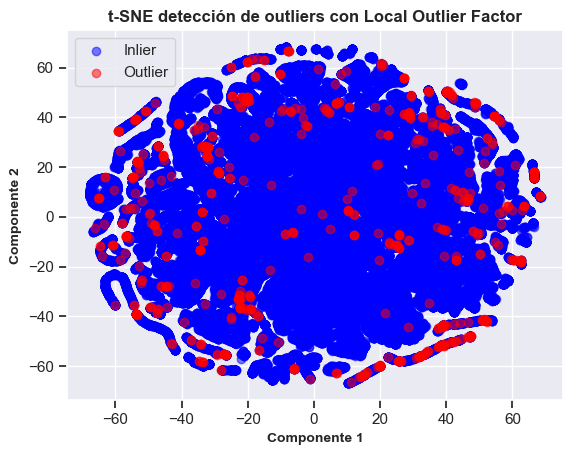

In [44]:
# Mapear los valores booleanos a categorías
dataset['outliers_lof_varunic'] = dataset['outliers_lof_varuni'].map({True: 'Outlier', False: 'Inlier'})

categorias = dataset['outliers_lof_varunic'].unique()
colores = ['blue', 'red']

for i, categoria in enumerate(categorias):
    indices = dataset['outliers_lof_varunic'] == categoria
    plt.scatter(data_tsne[indices, 0], data_tsne[indices, 1], color=colores[i], alpha=0.5, label=categoria)

plt.title('t-SNE detección de outliers con Local Outlier Factor', fontsize=12, weight='bold')
plt.xlabel('Componente 1', fontsize=10, weight='bold')
plt.ylabel('Componente 2', fontsize=10, weight='bold')
plt.legend()
plt.grid(True)
plt.show()

dataset = dataset.drop(columns=['outliers_lof_varunic'])

In [96]:
# Identificar los outliers (puntos con scores negativos)
outliers = data_num[outlier_scores == -1]

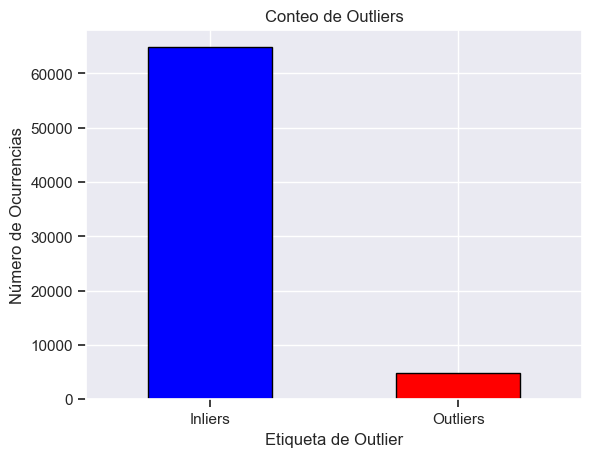

In [97]:
# Visualizar los resultados (por ejemplo, en una gráfica de barras)
outlier_counts = data_outliers['Outlier'].value_counts()
outlier_counts.plot(kind='bar', color=['blue', 'red'], edgecolor='black')
plt.title('Conteo de Outliers')
plt.xlabel('Etiqueta de Outlier')
plt.ylabel('Número de Ocurrencias')
plt.xticks([0, 1], ['Inliers', 'Outliers'], rotation=0)
plt.show()

In [100]:
data_outliers

,cro_cant_dias_publicar,proveedores_participantes,ofertas_confirmadas,dias_recepción_doc_soporte_fisico,duracion_contrato_dias,cant_total_bienes,cant_total_servicios,P_monto_total_procesos,P_cant_proveedores,Outlier
0,2.0,1.000000,0.75,2.000,-0.247761,136.420833,0.00,2.003552,3.0,1
1,1.0,-0.166667,-0.50,1.375,-0.179104,16.568750,0.00,-0.171442,-1.0,1
2,0.0,0.833333,0.25,0.875,0.805970,15.491667,0.00,1.970950,0.0,1
3,2.0,0.500000,0.75,0.000,0.805970,4.170833,6.50,1.601740,0.0,1
4,2.0,0.666667,1.00,3.875,0.089552,11.654167,0.00,4.165034,9.0,-1
...,...,...,...,...,...,...,...,...,...,...
69681,0.0,-0.500000,-0.50,0.000,0.358209,-0.008333,0.25,-0.171442,-1.0,-1
69682,0.0,-0.500000,-0.50,0.000,0.268657,0.429167,0.00,-0.171442,-1.0,1
69683,0.0,-0.500000,-0.50,0.000,-0.226866,-0.008333,12.75,-0.171442,-1.0,1
69684,0.0,-0.500000,-0.50,0.000,0.268657,0.262500,0.00,-0.171442,-1.0,1


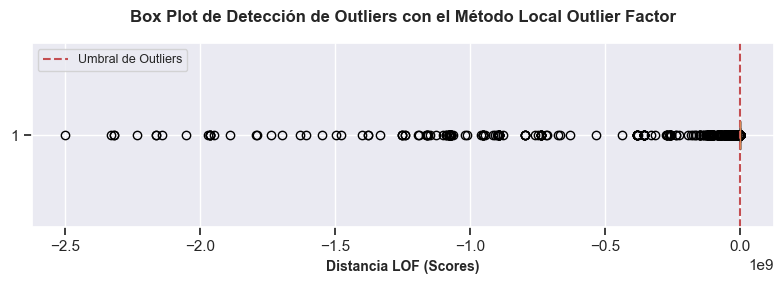

In [103]:
lof_distances = lof.negative_outlier_factor_

# Graficar el boxplot con las distancias
plt.figure(figsize=(8, 3))
plt.boxplot(lof_distances, vert=False)  # Boxplot de las distancias (outlier scores)
plt.axvline(x=threshold, color='r', linestyle='--', label='Umbral de Outliers')

# Configuración de etiquetas y leyenda
plt.xlabel('Distancia LOF (Scores)', fontsize=10, weight='bold')
plt.title('Box Plot de Detección de Outliers con el Método Local Outlier Factor', fontsize=12, weight='bold', pad=15)
plt.legend(fontsize=9)

plt.tight_layout()
plt.show()


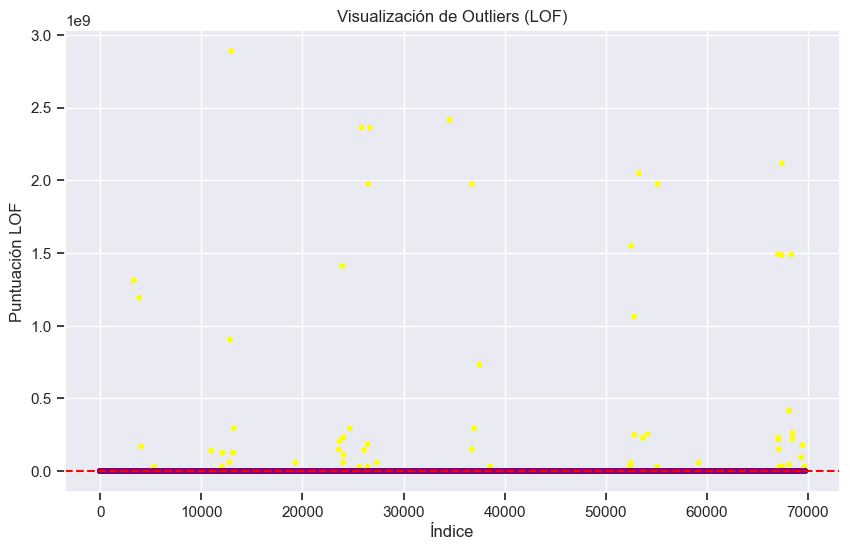

In [45]:
# Visualizar los outliers
plt.figure(figsize=(10, 6))
plt.scatter(range(len(lof_scores)), lof_scores, 
            c=['yellow' if i == -1 else 'purple' for i in y_pred], s=10)
plt.axhline(y=np.percentile(lof_scores, 99), color='red', linestyle='--')  # Umbral visual
plt.title('Visualización de Outliers (LOF)')
plt.xlabel('Índice')
plt.ylabel('Puntuación LOF')
plt.show()

In [111]:
data_outliers

,cro_cant_dias_publicar,proveedores_participantes,ofertas_confirmadas,dias_recepción_doc_soporte_fisico,duracion_contrato_dias,cant_total_bienes,cant_total_servicios,P_monto_total_procesos,P_cant_proveedores,Outlier,outliers_lof_varuni
0,2.0,1.000000,0.75,2.000,-0.247761,136.420833,0.00,2.003552,3.0,1,False
1,1.0,-0.166667,-0.50,1.375,-0.179104,16.568750,0.00,-0.171442,-1.0,1,False
2,0.0,0.833333,0.25,0.875,0.805970,15.491667,0.00,1.970950,0.0,1,False
3,2.0,0.500000,0.75,0.000,0.805970,4.170833,6.50,1.601740,0.0,1,False
4,2.0,0.666667,1.00,3.875,0.089552,11.654167,0.00,4.165034,9.0,-1,True
...,...,...,...,...,...,...,...,...,...,...,...
69681,0.0,-0.500000,-0.50,0.000,0.358209,-0.008333,0.25,-0.171442,-1.0,-1,True
69682,0.0,-0.500000,-0.50,0.000,0.268657,0.429167,0.00,-0.171442,-1.0,1,False
69683,0.0,-0.500000,-0.50,0.000,-0.226866,-0.008333,12.75,-0.171442,-1.0,1,False
69684,0.0,-0.500000,-0.50,0.000,0.268657,0.262500,0.00,-0.171442,-1.0,1,False


In [98]:
dataset.to_csv(ruta_dataset_outlier+"procesosOutliers.csv", sep='|', encoding='utf-8-sig')

## Isolation Forest

In [56]:
#traemos los datos y los normalizamos para que todos los métodos trabajen con los mismos datos
data_num = data_procesos_num[['cro_cant_dias_publicar','proveedores_participantes','ofertas_confirmadas','dias_recepción_doc_soporte_fisico','duracion_contrato_dias','cant_total_bienes','cant_total_servicios','P_monto_total_procesos','P_cant_proveedores']]

data_num.fillna(0, inplace=True)

# Crear la instancia del escalador
scaler = RobustScaler()

# Escalar los datos y mantenerlos como DataFrame
data_num_rs = pd.DataFrame(
    scaler.fit_transform(data_num),
    columns=data_num.columns,
    index=data_num.index
)
data_outliers =data_num_rs
data_outliers


C:\Users\Vanina\AppData\Local\Temp\ipykernel_9136\2602666660.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_num.fillna(0, inplace=True)


,cro_cant_dias_publicar,proveedores_participantes,ofertas_confirmadas,dias_recepción_doc_soporte_fisico,duracion_contrato_dias,cant_total_bienes,cant_total_servicios,P_monto_total_procesos,P_cant_proveedores
0,2.0,1.000000,0.75,2.000,-0.247761,136.420833,0.00,2.003552,3.0
1,1.0,-0.166667,-0.50,1.375,-0.179104,16.568750,0.00,-0.171442,-1.0
2,0.0,0.833333,0.25,0.875,0.805970,15.491667,0.00,1.970950,0.0
3,2.0,0.500000,0.75,0.000,0.805970,4.170833,6.50,1.601740,0.0
4,2.0,0.666667,1.00,3.875,0.089552,11.654167,0.00,4.165034,9.0
...,...,...,...,...,...,...,...,...,...
69681,0.0,-0.500000,-0.50,0.000,0.358209,-0.008333,0.25,-0.171442,-1.0
69682,0.0,-0.500000,-0.50,0.000,0.268657,0.429167,0.00,-0.171442,-1.0
69683,0.0,-0.500000,-0.50,0.000,-0.226866,-0.008333,12.75,-0.171442,-1.0
69684,0.0,-0.500000,-0.50,0.000,0.268657,0.262500,0.00,-0.171442,-1.0


In [ ]:
# Entrenar el modelo Isolation Forest
clf = IsolationForest(contamination=0.01) #se elige el umbral del 1% de outliers según los métodos previos
clf.fit(data_outliers)

# Predecir los outliers
y_pred = clf.predict(data_outliers)


data_outliers['outliers_IF_varuni']=y_pred == -1
dataset['outliers_IF_varuni']=y_pred == -1

# Etiquetar outliers como -1, inliers como 1
utliers = data_outliers[data_outliers['outliers_IF_varuni']]
inliers = data_outliers[~data_outliers['outliers_IF_varuni']]

In [63]:
outliers

,cro_cant_dias_publicar,proveedores_participantes,ofertas_confirmadas,dias_recepción_doc_soporte_fisico,duracion_contrato_dias,cant_total_bienes,cant_total_servicios,P_monto_total_procesos,P_cant_proveedores
241,2.0,4.000000,3.50,3.375,-0.268657,0.291667,48.0,-0.171442,-1.0
471,2.0,3.333333,0.00,3.125,0.820896,-0.008333,2462.5,627.285864,0.0
478,0.0,3.833333,4.00,1.250,0.805970,49.425000,0.0,0.808825,11.0
568,2.0,3.500000,3.25,1.125,-0.205970,-0.008333,131975.0,2.413105,2.0
842,0.0,4.166667,3.75,0.000,0.000000,365.741667,0.0,2.065884,8.0
...,...,...,...,...,...,...,...,...,...
68065,2.0,-0.166667,-0.50,0.000,0.805970,41666.658333,63750000.0,-0.171442,-1.0
68872,2.0,1.666667,0.00,9.125,0.089552,8333.325000,0.0,-0.171442,-1.0
68873,2.0,3.666667,0.50,8.875,1.522388,24999.995833,0.0,-0.171442,-1.0
68926,2.0,3.333333,3.50,1.625,0.805970,-0.008333,12960.0,-0.171442,-1.0


In [65]:
#cantidad de casos detectados

# Contar el número de outliers
n_outliers = data_outliers[data_outliers['outliers_IF_varuni'] == -1].shape[0]
print("Número de outliers:", n_outliers)

Número de outliers: 0


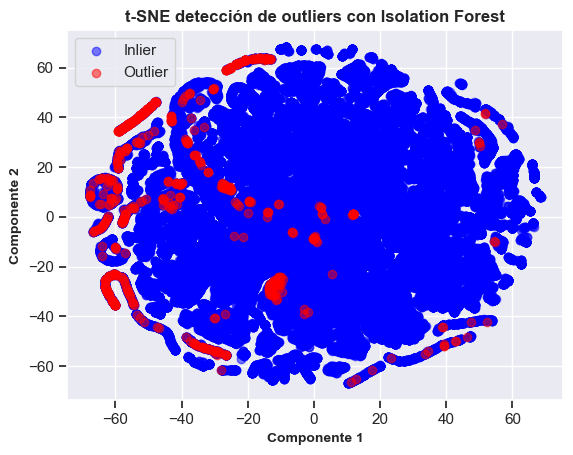

In [67]:
# Mapear los valores booleanos a categorías
dataset['outliers_IF_varunic'] = dataset['outliers_IF_varuni'].map({True: 'Outlier', False: 'Inlier'})


categorias = dataset['outliers_IF_varunic'].unique()
colores = ['blue', 'red']

for i, categoria in enumerate(categorias):
    indices = dataset['outliers_IF_varunic'] == categoria
    plt.scatter(data_tsne[indices, 0], data_tsne[indices, 1], color=colores[i], alpha=0.5, label=categoria)

plt.title('t-SNE detección de outliers con Isolation Forest', fontsize=12, weight='bold')
plt.xlabel('Componente 1', fontsize=10, weight='bold')
plt.ylabel('Componente 2', fontsize=10, weight='bold')
plt.legend()
plt.grid(True)
plt.show()

dataset = dataset.drop(columns=['outliers_IF_varunic'])

In [81]:
# Entrenar el modelo Isolation Forest para dataste completo
clf = IsolationForest(contamination=0.1) #se elige el umbral del 5% de outliers según los métodos previos
clf.fit(data_proveedores_num)

# Predecir los outliers
y_pred = clf.predict(data_proveedores_num)

# Etiquetar outliers como -1, inliers como 1
outliers = data_proveedores_num[y_pred == -1]
inliers = data_proveedores_num[y_pred == 1]

dataset['outliers_IF_vartot']=y_pred == -1

C:\Users\Vanina\anaconda3\envs\tesis\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


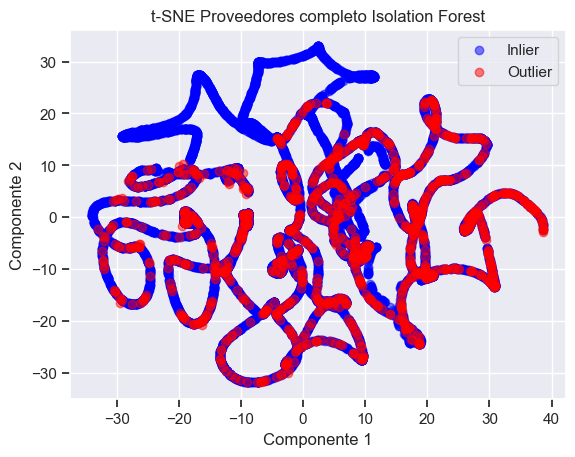

In [94]:
# Mapear los valores booleanos a categorías
dataset['outliers_IF_vartotc'] = dataset['outliers_IF_vartot'].map({True: 'Outlier', False: 'Inlier'})


categorias = dataset['outliers_IF_vartotc'].unique()
colores = ['blue', 'red']

for i, categoria in enumerate(categorias):
    indices = dataset['outliers_IF_vartotc'] == categoria
    plt.scatter(data_tsneC[indices, 0], data_tsneC[indices, 1], color=colores[i], alpha=0.5, label=categoria)

plt.title('t-SNE Proveedores completo Isolation Forest')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.legend()
plt.grid(True)
plt.show()

dataset = dataset.drop(columns=['outliers_IF_vartotc'])

### uCBLOF (unweighted Cluster-Based Local Outlier Factor (MCD)

In [ ]:
#traemos los datos y los normalizamos para que todos los métodos trabajen con los mismos datos
data_num = data_procesos_num[['cro_cant_dias_publicar','proveedores_participantes','ofertas_confirmadas','dias_recepción_doc_soporte_fisico','duracion_contrato_dias','cant_total_bienes','cant_total_servicios','P_monto_total_procesos','P_cant_proveedores']]

data_num.fillna(0, inplace=True)

# Crear la instancia del escalador
scaler = RobustScaler()

# Escalar los datos y mantenerlos como DataFrame
data_num_rs = pd.DataFrame(
    scaler.fit_transform(data_num),
    columns=data_num.columns,
    index=data_num.index
)
data_outliers =data_num_rs
data_outliers

In [102]:
#elegir el número de grupos
for k in range(2, 20):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(data_outliers)

    # Calcular Silhouette Score
    score = silhouette_score(data_outliers, labels)

    # Calcular tamaño de cada clúster
    unique, counts = np.unique(labels, return_counts=True)
    cluster_sizes = dict(zip(unique, counts))

    print(f"k = {k}, silhouette = {score:.3f}, tamaños de clústeres: {cluster_sizes}")

k = 2, silhouette = 0.999, tamaños de clústeres: {0: 69664, 1: 22}
k = 3, silhouette = 0.999, tamaños de clústeres: {0: 69655, 1: 27, 2: 4}
k = 4, silhouette = 0.999, tamaños de clústeres: {0: 69621, 1: 18, 2: 4, 3: 43}
k = 5, silhouette = 0.999, tamaños de clústeres: {0: 69620, 1: 4, 2: 10, 3: 42, 4: 10}
k = 6, silhouette = 0.998, tamaños de clústeres: {0: 69572, 1: 10, 2: 4, 3: 24, 4: 8, 5: 68}
k = 7, silhouette = 0.998, tamaños de clústeres: {0: 69526, 1: 10, 2: 4, 3: 29, 4: 8, 5: 95, 6: 14}
k = 8, silhouette = 0.998, tamaños de clústeres: {0: 69526, 1: 10, 2: 2, 3: 14, 4: 95, 5: 8, 6: 29, 7: 2}
k = 9, silhouette = 0.998, tamaños de clústeres: {0: 69526, 1: 10, 2: 12, 3: 2, 4: 8, 5: 12, 6: 94, 7: 2, 8: 20}
k = 10, silhouette = 0.998, tamaños de clústeres: {0: 69526, 1: 3, 2: 12, 3: 2, 4: 20, 5: 8, 6: 2, 7: 94, 8: 7, 9: 12}
k = 11, silhouette = 0.997, tamaños de clústeres: {0: 69492, 1: 3, 2: 12, 3: 2, 4: 8, 5: 46, 6: 12, 7: 7, 8: 2, 9: 20, 10: 82}
k = 12, silhouette = 0.997, tamaños

In [103]:
num_clusters = 15 # Número de clústeres a utilizar
kmeans = KMeans(n_clusters=num_clusters)


In [104]:
#aplicar kmeans al dataset uni, es decir al que se usó en los outliers univariados
kmeans.fit(data_outliers)

KMeans(n_clusters=15)

In [105]:
data_outliers

,cro_cant_dias_publicar,proveedores_participantes,ofertas_confirmadas,dias_recepción_doc_soporte_fisico,duracion_contrato_dias,cant_total_bienes,cant_total_servicios,P_monto_total_procesos,P_cant_proveedores
0,2.0,1.000000,0.75,2.000,-0.247761,136.420833,0.00,2.003552,3.0
1,1.0,-0.166667,-0.50,1.375,-0.179104,16.568750,0.00,-0.171442,-1.0
2,0.0,0.833333,0.25,0.875,0.805970,15.491667,0.00,1.970950,0.0
3,2.0,0.500000,0.75,0.000,0.805970,4.170833,6.50,1.601740,0.0
4,2.0,0.666667,1.00,3.875,0.089552,11.654167,0.00,4.165034,9.0
...,...,...,...,...,...,...,...,...,...
69681,0.0,-0.500000,-0.50,0.000,0.358209,-0.008333,0.25,-0.171442,-1.0
69682,0.0,-0.500000,-0.50,0.000,0.268657,0.429167,0.00,-0.171442,-1.0
69683,0.0,-0.500000,-0.50,0.000,-0.226866,-0.008333,12.75,-0.171442,-1.0
69684,0.0,-0.500000,-0.50,0.000,0.268657,0.262500,0.00,-0.171442,-1.0


In [106]:
# Obtenemos los centroides de los clústeres
centroides = kmeans.cluster_centers_

# Calculamos las distancias de los datos a los centroides
distancias_a_centroides = kmeans.transform(data_outliers)

# Calculamos el factor de localidad para cada punto
UCBLOF_scores = np.mean(distancias_a_centroides, axis=1)

# Creamos un modelo LOF para identificar outliers basados en UCBLOF_scores
lof_model = LocalOutlierFactor(n_neighbors=15, contamination=0.01)  # Ajusta los parámetros según tu caso
outliers = lof_model.fit_predict(data_outliers)

# Creamos una nueva columna con valores booleanos indicando si es outlier o no
data_outliers['Outlier'] = outliers == -1  # -1 representa outliers, por lo que será True, y otros valores serán False
cantidad_outliers = data_outliers['Outlier'].sum()
cantidad_outliers

697

In [107]:
# Agregamos los resultados de detección de outliers como una nueva columna al DataFrame original
dataset['Outlier_uCBLOF_varuni'] = data_outliers['Outlier']

outlier_count = dataset['Outlier_uCBLOF_varuni'].sum()
print("Número de outliers:", outlier_count)

Número de outliers: 697


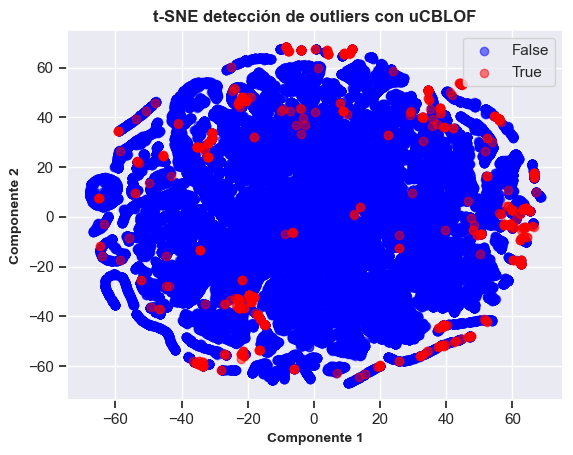

In [108]:
# Mapear los valores booleanos a categorías
dataset['Outlier_c_varuni'] = dataset['Outlier_uCBLOF_varuni'].map({-1: 'Outlier', 1: 'Inlier'})


categorias = dataset['Outlier_uCBLOF_varuni'].unique()
colores = ['blue', 'red']

for i, categoria in enumerate(categorias):
    indices = dataset['Outlier_uCBLOF_varuni'] == categoria
    plt.scatter(data_tsne[indices, 0], data_tsne[indices, 1], color=colores[i], alpha=0.5, label=categoria)

plt.title('t-SNE detección de outliers con uCBLOF', fontsize=12, weight='bold')
plt.xlabel('Componente 1', fontsize=10, weight='bold')
plt.ylabel('Componente 2', fontsize=10, weight='bold')

plt.legend()
plt.grid(True)
plt.show()

dataset = dataset.drop(columns=['Outlier_c_varuni'])

In [22]:
#dataset completo

In [53]:
#aplicar kmeans al dataset uni, es decir al que se usó en los outliers univariados
kmeans.fit(data_proveedores_num)

C:\Users\Vanina\anaconda3\envs\tesis\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(n_clusters=10)

In [58]:
# Obtenemos los centroides de los clústeres
centroides = kmeans.cluster_centers_

# Calculamos las distancias de los datos a los centroides
distancias_a_centroides = kmeans.transform(data_proveedores_num)

# Calculamos el factor de localidad para cada punto
UCBLOF_scores = np.mean(distancias_a_centroides, axis=1)

# Creamos un modelo LOF para identificar outliers basados en UCBLOF_scores
lof_model = LocalOutlierFactor(n_neighbors=20, contamination=0.07)  # Ajusta los parámetros según tu caso
outliers = lof_model.fit_predict(data_proveedores_num)

# Creamos una nueva columna con valores booleanos indicando si es outlier o no
dataset['Outlier_uCBLOF_vartot'] = outliers == -1  # -1 representa outliers, por lo que será True, y otros valores serán False
cantidad_outliers = dataset['Outlier_uCBLOF_vartot'].sum()
cantidad_outliers

845

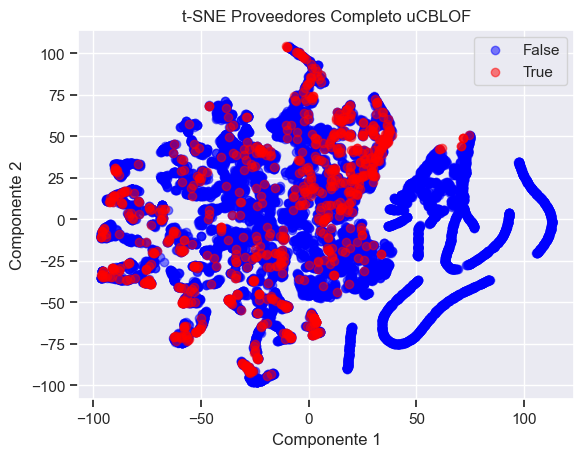

In [59]:
# Mapear los valores booleanos a categorías
dataset['Outlier_c_vartot'] = dataset['Outlier_uCBLOF_vartot'].map({-1: 'Outlier', 1: 'Inlier'})


categorias = dataset['Outlier_uCBLOF_vartot'].unique()
colores = ['blue', 'red']

for i, categoria in enumerate(categorias):
    indices = dataset['Outlier_uCBLOF_vartot'] == categoria
    plt.scatter(data_tsne[indices, 0], data_tsne[indices, 1], color=colores[i], alpha=0.5, label=categoria)

plt.title('t-SNE Proveedores Completo uCBLOF')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.legend()
plt.grid(True)
plt.show()

dataset = dataset.drop(columns=['Outlier_c_vartot'])

In [110]:
dataset.to_csv(ruta_dataset_outlier+"ProveedoresOutlierUniMulti.csv", sep='|', encoding='utf-8-sig')